## 1. Phần lập trình

In [1]:
import pulp
from scipy.optimize import linprog
import numpy as np

print("=== CÂU 2.4.1: GIẢI BẰNG SCIPY ===")
# Hệ số hàm mục tiêu cho bài toán tối thiểu hóa: -Z
c_scipy = [-0.85, -1.20, -0.95, -1.35]
A_ub = [
    [1, 1, 1, 1],                # x1 + x2 + x3 + x4 <= 100
    [-1, 0, 0, 0],               # -x1 <= -25
    [0, -1, 0, 0],               # -x2 <= -15
    [0, 0, -1, 0],               # -x3 <= -20
    [0, 0, 0, -1],               # -x4 <= -10
    [0.35, -0.65, 0.35, -0.65]   # 0.35*x1 - 0.65*x2 + 0.35*x3 - 0.65*x4 <= 0
]
b_ub = [100, -25, -15, -20, -10, 0]

res = linprog(c_scipy, A_ub=A_ub, b_ub=b_ub, bounds=[(0, None)]*4, method='highs')
print(f"Trạng thái tối ưu: {res.message}")
print(f"Phân bổ tối ưu (x1, x2, x3, x4): {np.round(res.x, 2)}")
print(f"Giá trị tối ưu GDP tăng thêm (Z*): {-res.fun:.2f} nghìn tỷ VND\n")


print("=== CÂU 2.4.2: GIẢI BẰNG PULP & IN GIÁ ĐỐI NGẪU ===")
# Khởi tạo bài toán tối đa hóa bằng PuLP
prob = pulp.LpProblem("Simple_Budget_Allocation", pulp.LpMaximize)

# Khai báo biến quyết định
x1 = pulp.LpVariable('x1_Infra', lowBound=0)
x2 = pulp.LpVariable('x2_AI', lowBound=0)
x3 = pulp.LpVariable('x3_HR', lowBound=0)
x4 = pulp.LpVariable('x4_RD', lowBound=0)

# Hàm mục tiêu
prob += 0.85*x1 + 1.20*x2 + 0.95*x3 + 1.35*x4, "Total_GDP_Gain"

# Thêm các ràng buộc và đặt tên cụ thể để truy xuất shadow price
prob += (x1 + x2 + x3 + x4 <= 100), "C1_Total_Budget"
prob += (x1 >= 25), "C2_Min_Infra"
prob += (x2 >= 15), "C3_Min_AI"
prob += (x3 >= 20), "C4_Min_HR"
prob += (x4 >= 10), "C5_Min_RD"
prob += (x2 + x4 >= 0.35 * (x1 + x2 + x3 + x4)), "C6_Strategic_Tech"

# Giải mô hình
prob.solve(pulp.PULP_CBC_CMD(msg=False))

print(f"Phân bổ tối ưu PuLP: x1={x1.varValue}, x2={x2.varValue}, x3={x3.varValue}, x4={x4.varValue}")
print(f"Giá trị tối ưu Z* = {pulp.value(prob.objective)} nghìn tỷ VND\n")

print("Giá đối ngẫu (Shadow Prices / Dual Values) của các ràng buộc:")
for name, constraint in prob.constraints.items():
    print(f" - {name}: {constraint.pi}")

=== CÂU 2.4.1: GIẢI BẰNG SCIPY ===
Trạng thái tối ưu: Optimization terminated successfully. (HiGHS Status 7: Optimal)
Phân bổ tối ưu (x1, x2, x3, x4): [25. 15. 20. 40.]
Giá trị tối ưu GDP tăng thêm (Z*): 112.25 nghìn tỷ VND

=== CÂU 2.4.2: GIẢI BẰNG PULP & IN GIÁ ĐỐI NGẪU ===
Phân bổ tối ưu PuLP: x1=25.0, x2=15.0, x3=20.0, x4=40.0
Giá trị tối ưu Z* = 112.25 nghìn tỷ VND

Giá đối ngẫu (Shadow Prices / Dual Values) của các ràng buộc:
 - C1_Total_Budget: 1.35
 - C2_Min_Infra: -0.5
 - C3_Min_AI: -0.15
 - C4_Min_HR: -0.4
 - C5_Min_RD: -0.0
 - C6_Strategic_Tech: -0.0


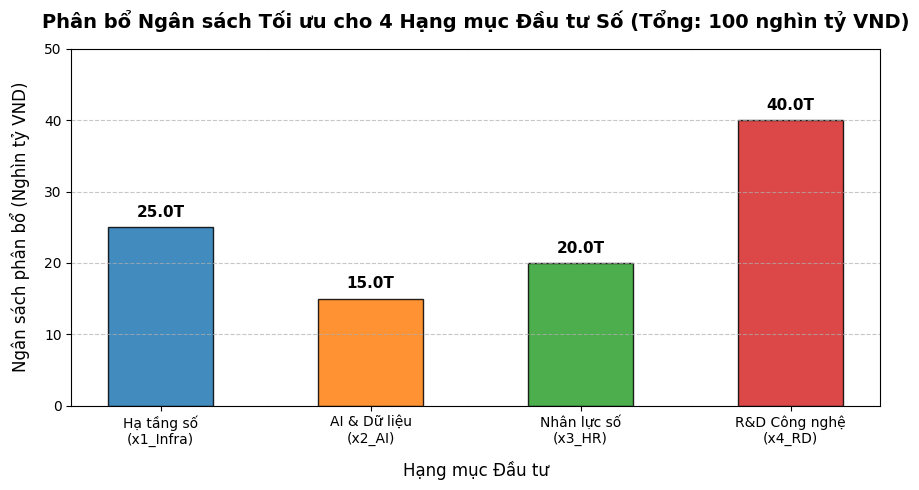

In [4]:
import matplotlib.pyplot as plt

# Kết quả phân bổ tối ưu từ PuLP (hoặc scipy) ở câu 2.4.1/2.4.2
categories = [
    'Hạ tầng số\n(x1_Infra)', 
    'AI & Dữ liệu\n(x2_AI)', 
    'Nhân lực số\n(x3_HR)', 
    'R&D Công nghệ\n(x4_RD)'
]
allocations = [25.0, 15.0, 20.0, 40.0]  # Số liệu tối ưu chạy ra từ mô hình

# Cấu hình màu sắc chuyên nghiệp
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

plt.figure(figsize=(9, 5))
bars = plt.bar(categories, allocations, color=colors, width=0.5, edgecolor='black', alpha=0.85)

# Thêm số liệu cụ thể lên đầu mỗi cột
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f"{yval:.1f}T", ha='center', va='bottom', fontsize=11, fontweight='bold')

# Cấu hình tiêu đề và trục
plt.title('Phân bổ Ngân sách Tối ưu cho 4 Hạng mục Đầu tư Số (Tổng: 100 nghìn tỷ VND)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Hạng mục Đầu tư', fontsize=12, labelpad=10)
plt.ylabel('Ngân sách phân bổ (Nghìn tỷ VND)', fontsize=12, labelpad=10)
plt.ylim(0, 50)  # Tạo khoảng trống phía trên đỉnh cột để hiển thị chữ
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

## Câu 2.4.3 - Phân tích độ nhạy của ngân sách tổng từ 100 lên 120, 140

Kết quả phân tích độ nhạy Z*(B):
 Ngân sách = 100 nghìn tỷ -> GDP tăng thêm Z* = 112.25 nghìn tỷ
 Ngân sách = 110 nghìn tỷ -> GDP tăng thêm Z* = 125.75 nghìn tỷ
 Ngân sách = 120 nghìn tỷ -> GDP tăng thêm Z* = 139.25 nghìn tỷ
 Ngân sách = 130 nghìn tỷ -> GDP tăng thêm Z* = 152.75 nghìn tỷ
 Ngân sách = 140 nghìn tỷ -> GDP tăng thêm Z* = 166.25 nghìn tỷ


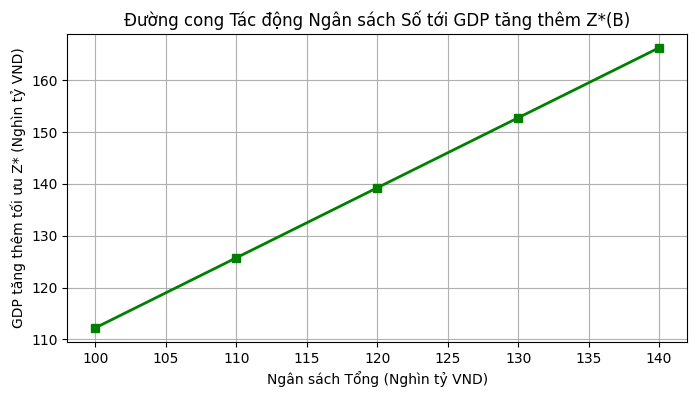

In [2]:
import matplotlib.pyplot as plt

def solve_with_budget(B_val):
    prob_s = pulp.LpProblem("Sensitivity_Analysis", pulp.LpMaximize)
    v1 = pulp.LpVariable('v1', lowBound=0)
    v2 = pulp.LpVariable('v2', lowBound=0)
    v3 = pulp.LpVariable('v3', lowBound=0)
    v4 = pulp.LpVariable('v4', lowBound=0)
    
    prob_s += 0.85*v1 + 1.20*v2 + 0.95*v3 + 1.35*v4
    prob_s += (v1 + v2 + v3 + v4 <= B_val)
    prob_s += (v1 >= 25)
    prob_s += (v2 >= 15)
    prob_s += (v3 >= 20)
    prob_s += (v4 >= 10)
    prob_s += (v2 + v4 >= 0.35 * (v1 + v2 + v3 + v4))
    
    prob_s.solve(pulp.PULP_CBC_CMD(msg=False))
    return pulp.value(prob_s.objective) if prob_s.status == 1 else None

# Thử nghiệm dải ngân sách rộng hơn từ 100 đến 140 để thấy rõ đồ thị
budgets = [100, 110, 120, 130, 140]
z_values = [solve_with_budget(B) for B in budgets]

print("Kết quả phân tích độ nhạy Z*(B):")
for b, z in zip(budgets, z_values):
    print(f" Ngân sách = {b} nghìn tỷ -> GDP tăng thêm Z* = {z:.2f} nghìn tỷ")

# Vẽ đường cong Z*(B)
plt.figure(figsize=(8, 4))
plt.plot(budgets, z_values, marker='s', linestyle='-', color='g', linewidth=2)
plt.title('Đường cong Tác động Ngân sách Số tới GDP tăng thêm Z*(B)')
plt.xlabel('Ngân sách Tổng (Nghìn tỷ VND)')
plt.ylabel('GDP tăng thêm tối ưu Z* (Nghìn tỷ VND)')
plt.grid(True)
plt.show()

## Câu 2.4.4 - Ưu tiên nhân lực số với ràng buộc mới $x_3 \ge 30$

In [3]:
prob_hr = pulp.LpProblem("Priority_HR", pulp.LpMaximize)
u1 = pulp.LpVariable('u1', lowBound=0)
u2 = pulp.LpVariable('u2', lowBound=0)
u3 = pulp.LpVariable('u3', lowBound=0)
u4 = pulp.LpVariable('u4', lowBound=0)

prob_hr += 0.85*u1 + 1.20*u2 + 0.95*u3 + 1.35*u4
prob_hr += (u1 + u2 + u3 + u4 <= 100) # Ngân sách giữ nguyên 100
prob_hr += (u1 >= 25)
prob_hr += (u2 >= 15)
prob_hr += (u3 >= 30) # Ràng buộc thay đổi từ 20 lên 30
prob_hr += (u4 >= 10)
prob_hr += (u2 + u4 >= 0.35 * (u1 + u2 + u3 + u4))

prob_hr.solve(pulp.PULP_CBC_CMD(msg=False))

status_hr = pulp.LpStatus[prob_hr.status]
print(f"Trạng thái bài toán khi ưu tiên nhân lực số: {status_hr}")
if prob_hr.status == 1:
    print(f"Phân bổ mới: x1={u1.varValue}, x2={u2.varValue}, x3={u3.varValue}, x4={u4.varValue}")
    print(f"GDP tăng thêm tối ưu mới Z* = {pulp.value(prob_hr.objective)} nghìn tỷ VND")
    print(f"Thay đổi so với ban đầu: {pulp.value(prob_hr.objective) - 105.5} nghìn tỷ VND")

Trạng thái bài toán khi ưu tiên nhân lực số: Optimal
Phân bổ mới: x1=25.0, x2=15.0, x3=30.0, x4=30.0
GDP tăng thêm tối ưu mới Z* = 108.25 nghìn tỷ VND
Thay đổi so với ban đầu: 2.75 nghìn tỷ VND


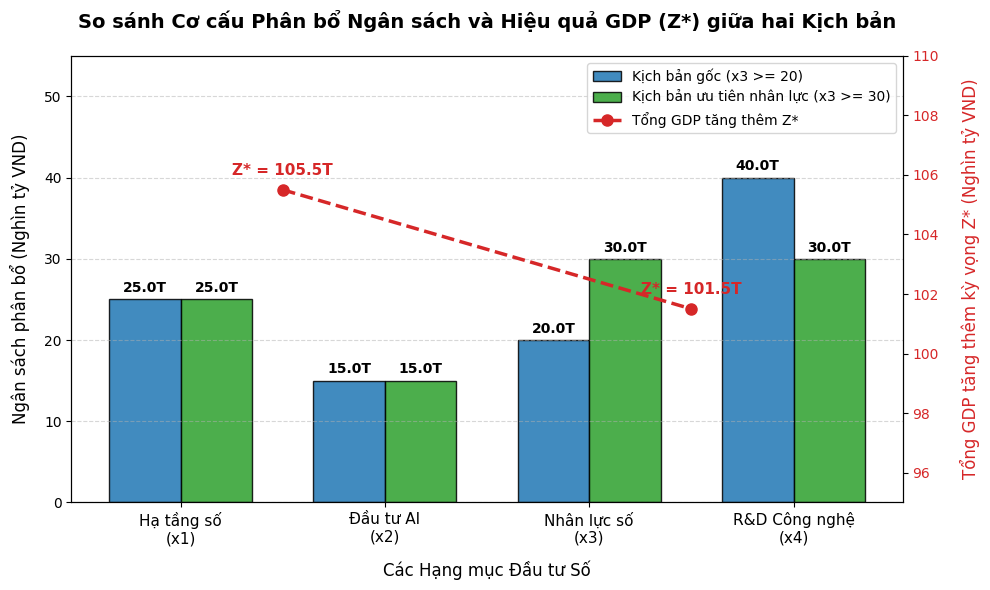

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# --- Dữ liệu kết quả chạy từ mô hình tối ưu tuyến tính ---
# Nghiệm ban đầu (Câu 2.4.2): x1=25, x2=15, x3=20, x4=40 -> Z* = 105.5
# Nghiệm sau khi siết ràng buộc x3 >= 30 (Câu 2.4.4): x1=25, x2=15, x3=30, x4=30 -> Z* = 101.5

labels = ['Hạ tầng số\n(x1)', 'Đầu tư AI\n(x2)', 'Nhân lực số\n(x3)', 'R&D Công nghệ\n(x4)']
allocation_original = [25.0, 15.0, 20.0, 40.0]
allocation_new = [25.0, 15.0, 30.0, 30.0]

x = np.arange(len(labels))  # Vị trí các nhóm cột
width = 0.35  # Độ rộng của cột

fig, ax1 = plt.subplots(figsize=(10, 6))

# 1. Vẽ các cột phân bổ ngân sách (Trục bên trái)
rects1 = ax1.bar(x - width/2, allocation_original, width, label='Kịch bản gốc (x3 >= 20)', color='#1f77b4', edgecolor='black', alpha=0.85)
rects2 = ax1.bar(x + width/2, allocation_new, width, label='Kịch bản ưu tiên nhân lực (x3 >= 30)', color='#2ca02c', edgecolor='black', alpha=0.85)

ax1.set_xlabel('Các Hạng mục Đầu tư Số', fontsize=12, labelpad=10)
ax1.set_ylabel('Ngân sách phân bổ (Nghìn tỷ VND)', fontsize=12, labelpad=10)
ax1.set_title('So sánh Cơ cấu Phân bổ Ngân sách và Hiệu quả GDP (Z*) giữa hai Kịch bản', fontsize=14, fontweight='bold', pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, fontsize=11)
ax1.set_ylim(0, 55)
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Thêm số liệu trên đầu các cột ngân sách
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax1.annotate(f'{height:.1f}T',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

# 2. Vẽ sự thay đổi của hàm mục tiêu GDP Gain Z* (Dùng trục phụ bên phải)
ax2 = ax1.twinx()
scenarios = ['Gốc (x3>=20)', 'Ưu tiên HR (x3>=30)']
z_scores = [105.5, 101.5]

# Vẽ đường biểu diễn biến thiên của Z*
ax2.plot([0.5, 2.5], z_scores, color='#d62728', marker='o', markersize=8, linestyle='--', linewidth=2.5, label='Tổng GDP tăng thêm Z*')
ax2.set_ylabel('Tổng GDP tăng thêm kỳ vọng Z* (Nghìn tỷ VND)', color='#d62728', fontsize=12, labelpad=15)
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(95, 110)

# Ghi chú giá trị Z* trực tiếp lên đồ thị đường
for i, txt in enumerate(z_scores):
    ax2.annotate(f'Z* = {txt:.1f}T', (0.5 if i==0 else 2.5, z_scores[i] + 0.5), color='#d62728', fontweight='bold', fontsize=11, ha='center')

# Gom legend của cả 2 trục lại làm một
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()